In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
csv_path = Path(r"C:/Users/maria/Desktop/UNI/TGF/TFG/escenarios/iid/results_iid/metricas_por_hospital_y_ronda_fedavg.csv")
df = pd.read_csv(csv_path)

df.head()

,ronda,hospital,train_loss,train_acc,test_loss,test_acc,train_samples,val_samples,test_samples
0,1,Hospital_1,0.149169,0.946958,0.056950,0.983051,8842,1768,1180
1,1,Hospital_2,0.177577,0.948547,0.046554,0.988983,8843,1768,1180
2,1,Hospital_3,0.163965,0.941875,0.036988,0.994068,8843,1768,1180
3,1,Hospital_4,0.155109,0.948095,0.042268,0.988983,8843,1768,1180
4,1,Hospital_5,0.159475,0.949452,0.042819,0.988136,8843,1768,1180


In [3]:
# Ver el contenido del DataFrame
print(df.shape)
df

(25, 9)


,ronda,hospital,train_loss,train_acc,test_loss,test_acc,train_samples,val_samples,test_samples
0,1,Hospital_1,0.149169,0.946958,0.056950,0.983051,8842,1768,1180
1,1,Hospital_2,0.177577,0.948547,0.046554,0.988983,8843,1768,1180
2,1,Hospital_3,0.163965,0.941875,0.036988,0.994068,8843,1768,1180
3,1,Hospital_4,0.155109,0.948095,0.042268,0.988983,8843,1768,1180
4,1,Hospital_5,0.159475,0.949452,0.042819,0.988136,8843,1768,1180
5,2,Hospital_1,0.024396,0.993553,0.011418,0.997458,8842,1768,1180
6,2,Hospital_2,0.031662,0.991519,0.007273,0.998305,8843,1768,1180
7,2,Hospital_3,0.024222,0.992084,0.002681,1.000000,8843,1768,1180
8,2,Hospital_4,0.028684,0.992310,0.009495,0.998305,8843,1768,1180
9,2,Hospital_5,0.030029,0.991745,0.005249,0.998305,8843,1768,1180


In [4]:
# Media por ronda
df_round = df.groupby("ronda", as_index=False).agg({
    "test_loss": "mean",
    "test_acc": "mean",
    "train_loss": "mean",
    "train_acc": "mean"
})

df_round

,ronda,test_loss,test_acc,train_loss,train_acc
0,1,0.045116,0.988644,0.161059,0.946985
1,2,0.007223,0.998475,0.027799,0.992242
2,3,0.004184,0.998983,0.014779,0.995793
3,4,0.004164,0.998814,0.012065,0.996517
4,5,0.004503,0.998814,0.010080,0.996811


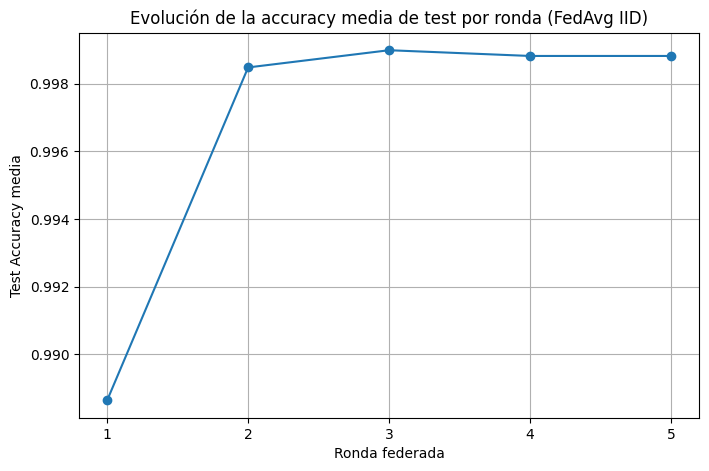

In [5]:
# gráfica de accuracy media por ronda
plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["test_acc"], marker="o")
plt.xlabel("Ronda federada")
plt.ylabel("Test Accuracy media")
plt.title("Evolución de la accuracy media de test por ronda (FedAvg IID)")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.show()

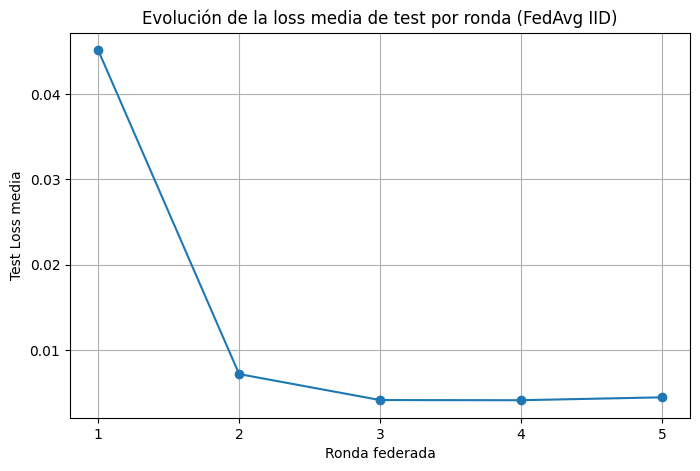

In [6]:
# gráfica de loss media por ronda
plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["test_loss"], marker="o")
plt.xlabel("Ronda federada")
plt.ylabel("Test Loss media")
plt.title("Evolución de la loss media de test por ronda (FedAvg IID)")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.show()

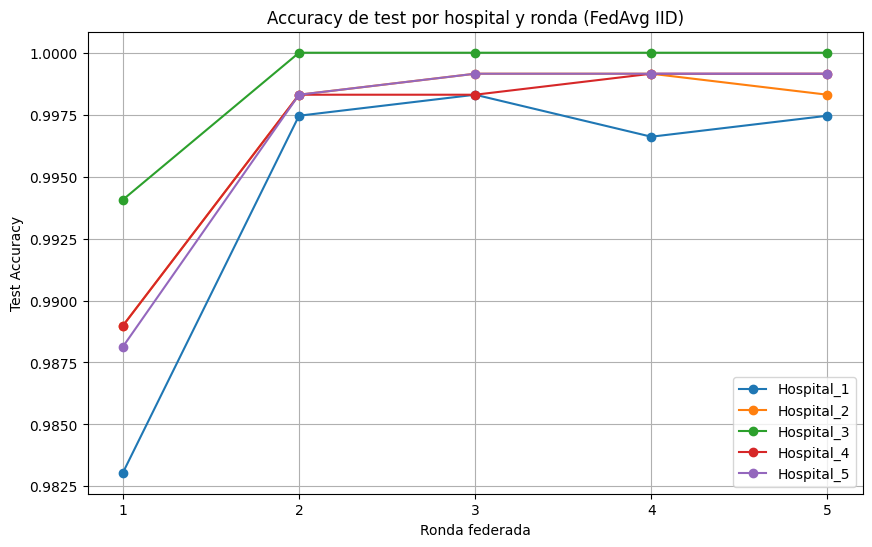

In [7]:
# accuracy de test por hospital
plt.figure(figsize=(10,6))

for hospital in df["hospital"].unique():
    df_h = df[df["hospital"] == hospital]
    plt.plot(df_h["ronda"], df_h["test_acc"], marker="o", label=hospital)

plt.xlabel("Ronda federada")
plt.ylabel("Test Accuracy")
plt.title("Accuracy de test por hospital y ronda (FedAvg IID)")
plt.xticks(sorted(df["ronda"].unique()))
plt.grid(True)
plt.legend()
plt.show()

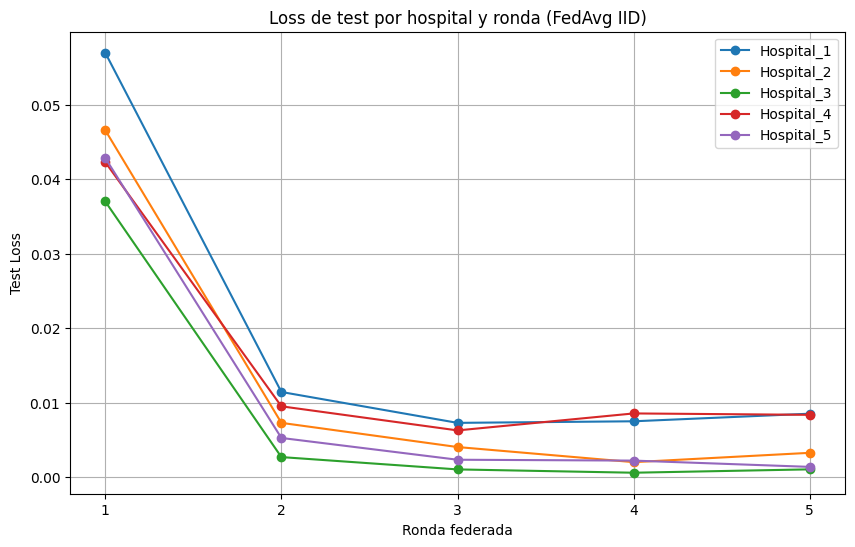

In [8]:
# loss de test por hospital
plt.figure(figsize=(10,6))

for hospital in df["hospital"].unique():
    df_h = df[df["hospital"] == hospital]
    plt.plot(df_h["ronda"], df_h["test_loss"], marker="o", label=hospital)

plt.xlabel("Ronda federada")
plt.ylabel("Test Loss")
plt.title("Loss de test por hospital y ronda (FedAvg IID)")
plt.xticks(sorted(df["ronda"].unique()))
plt.grid(True)
plt.legend()
plt.show()

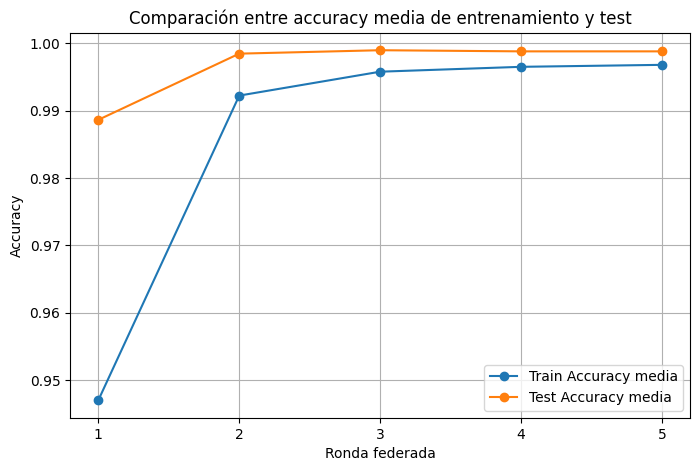

In [9]:
# accuracy de train vs test media
plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["train_acc"], marker="o", label="Train Accuracy media")
plt.plot(df_round["ronda"], df_round["test_acc"], marker="o", label="Test Accuracy media")

plt.xlabel("Ronda federada")
plt.ylabel("Accuracy")
plt.title("Comparación entre accuracy media de entrenamiento y test")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.legend()
plt.show()

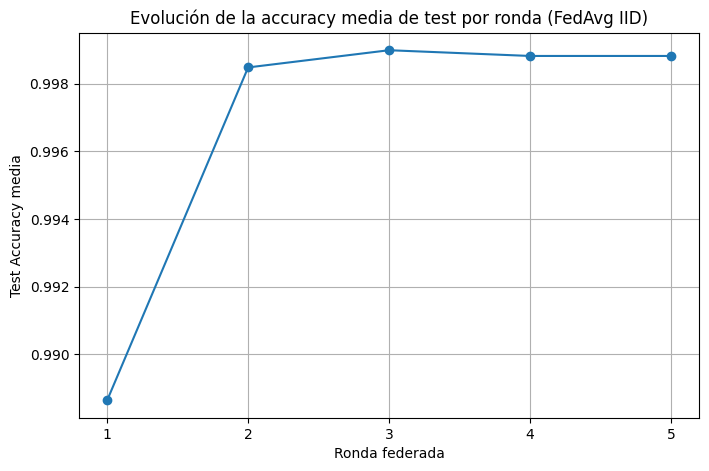

In [10]:
# guardar las gráficas
output_dir = csv_path.parent / "graficas"
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["test_acc"], marker="o")
plt.xlabel("Ronda federada")
plt.ylabel("Test Accuracy media")
plt.title("Evolución de la accuracy media de test por ronda (FedAvg IID)")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.savefig(output_dir / "accuracy_media_por_ronda.png", bbox_inches="tight")
plt.show()

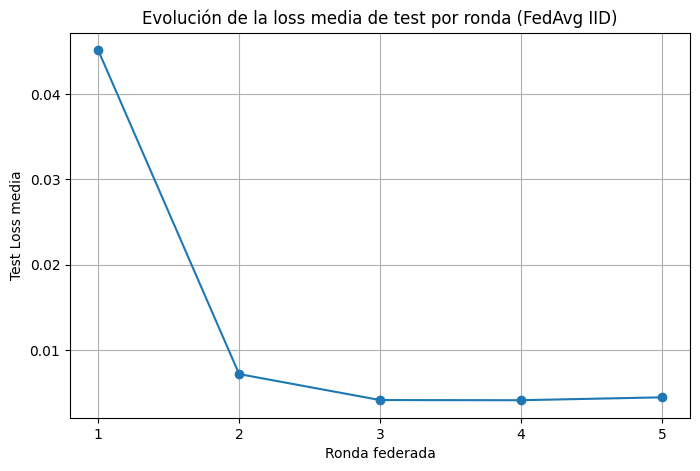

In [11]:
plt.figure(figsize=(8,5))
plt.plot(df_round["ronda"], df_round["test_loss"], marker="o")
plt.xlabel("Ronda federada")
plt.ylabel("Test Loss media")
plt.title("Evolución de la loss media de test por ronda (FedAvg IID)")
plt.xticks(df_round["ronda"])
plt.grid(True)
plt.savefig(output_dir / "loss_media_por_ronda.png", bbox_inches="tight")
plt.show()

In [12]:
# resumen
df_round = df.groupby("ronda", as_index=False).agg({
    "train_loss": "mean",
    "train_acc": "mean",
    "test_loss": "mean",
    "test_acc": "mean"
})

df_round = df_round.rename(columns={
    "ronda": "Ronda",
    "train_loss": "Train Loss Medio",
    "train_acc": "Train Acc Media",
    "test_loss": "Test Loss Medio",
    "test_acc": "Test Acc Media"
})

df_round = df_round.round(4)

df_round.to_csv(output_dir / "resumen_metricas_por_ronda.csv", index=False)